In [1]:
# add src3 to sys.path for imports
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent / "src3"))

In [101]:
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from io_utils import save, load, append, preview, Timing
from overhead_pipeline import app, capture_overhead, process_overhead, visualize_overhead
from vibrations_pipeline import capture_vibrations

In [3]:
# Run once after kernel restart — keeps Modal app alive for the whole session.
# Must use async with app.run.aio() in Jupyter; the sync app.run() fights Jupyter's event loop.
# _app_ctx holds the context manager so it isn't garbage collected (which would stop the app).
_app_ctx = app.run.aio()
await _app_ctx.__aenter__()

In [4]:
EXPERIMENT_DIR = Path('/home/ethantu/workspace/good-vibrations/data2')
BASE_SAMPLE_DIR = Path(EXPERIMENT_DIR) / 'samples'
BASE_OUTPUT_DIR = Path(EXPERIMENT_DIR) / 'outputs'

for path in [BASE_SAMPLE_DIR, BASE_OUTPUT_DIR]: os.makedirs(path, exist_ok=True)

In [5]:
def count_dirs(path): return sum(1 for path in path.iterdir() if path.is_dir()) if path.exists() else 0
def make_id(path): return f"{count_dirs(path):06d}"

In [104]:
def get_key(metadata, mask): return (metadata['box'], metadata['object'], metadata['n_objects'], mask.shape)

def show_box_coverage(box_coverage:dict, sample_dir:str|Path=None, plot:bool=True):
    metadata = {'sample_id': ''} if sample_dir is None else {k: v for d in load(sample_dir / "metadata.jsonl") for k, v in d.items()}
    with Timing(f"[Sample {metadata['sample_id']}] box coverage: "):
        if sample_dir is not None:
            mask = np.array(load(sample_dir / "outputs/02_segment_mask.png"))

            # update box coverage
            key = get_key(metadata, mask)
            if key not in box_coverage: box_coverage[key] = {'mask': np.zeros(mask.shape), 'sample_ids': []}
            box_coverage[key]['mask'] += mask
            box_coverage[key]['sample_ids'].append(metadata['sample_id'])

            keys = [key]
        else:
            keys = box_coverage.keys()

        if plot:
            for key in keys:
                box, obj, n_objects, shape = key
                fig, ax = plt.subplots()
                im = ax.imshow(box_coverage[key]['mask'], cmap='Blues')
                plt.colorbar(im, ax=ax)
                ax.set(title=f"Box Coverage\n{n_objects} {obj} in {box} box ({shape[1]}×{shape[0]}, {len(box_coverage[key]['sample_ids'])} samples)", xlabel='x (downsampled pixel space)', ylabel='y (downsampled pixel space)')
                plt.show()

    return box_coverage

[Sample 000004] box coverage:   0.28 ms
[Sample 000002] box coverage:   0.17 ms
[Sample 000000] box coverage:   0.14 ms
[Sample 000003] box coverage:   0.13 ms
[Sample 000001] box coverage:   0.13 ms


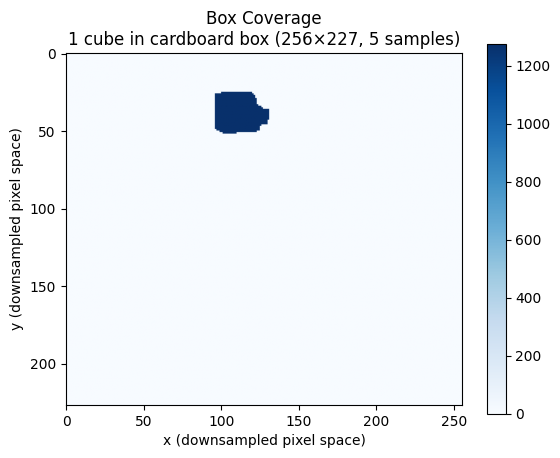

[Sample ] box coverage:  61.40 ms


In [105]:
# initialize box coverage
box_coverage = {}
for sample_dir in BASE_SAMPLE_DIR.iterdir(): box_coverage = show_box_coverage(box_coverage, sample_dir, plot=False)
show_box_coverage(box_coverage, plot=True)
plt.show()

In [99]:
def run_experiment(obj_params, overhead_params, vibrate_params, box_coverage, cam, run_opt, overhead_cam, capture_image_fxn, play_audio_fxn, capture_n_frames_fxn, verbose:int=1, do_save:bool=True):

    output_id = make_id(BASE_OUTPUT_DIR)
    output_dir = BASE_OUTPUT_DIR / output_id
    is_empty_box = obj_params['n_objects'] == 0
    metadata = obj_params | overhead_params | dict(output_dir=str(output_dir), output_id=output_id, is_empty_box=is_empty_box)
    append([{str(k) if isinstance(k, Path) else k: v} for k, v in metadata.items()], output_dir / 'metadata.jsonl', do_save)

    # capture and segment overhead image
    raw_overhead = capture_overhead(overhead_cam, capture_image_fxn, output_dir, do_save=do_save)
    process_overhead(raw_overhead, output_dir, **overhead_params['resize_params'], prompt=overhead_params['prompt'], is_empty_box=is_empty_box, verbose=verbose, do_save=do_save)

    # speaker for loop
    speaker = vibrate_params['speakers'][0]
    sample_id  = make_id(BASE_SAMPLE_DIR)
    sample_dir = BASE_SAMPLE_DIR / sample_id
    overhead = visualize_overhead(speaker, sample_dir, output_dir, is_empty_box, verbose, do_save=do_save)

    # update box coverage
    box_coverage = show_box_coverage(box_coverage, sample_dir, plot=verbose >= 1)

    if verbose >= 1: preview(overhead, 'image')
    raw_vibrations = capture_vibrations(cam, run_opt, speaker, play_audio_fxn, capture_n_frames_fxn, vibrate_params['audio'], sample_dir, output_dir, verbose, do_save)
    if verbose >= 1: preview(raw_vibrations, 'vibration_image')
    if verbose >= 3: preview(raw_vibrations, 'vibration_video')

    # process_vibrations(raw_vibrations) # launch pckl
    return

[output 000004] Box is not empty
[output 000004] resize:  19.34 ms
[output 000004] segment: 1637.02 ms
[output 000004] downsample:   0.69 ms
[output 000004] center of mass:   0.21 ms
[sample 000004] load cached artifacts:   0.09 ms
[sample 000004] make overhead:  18.66 ms


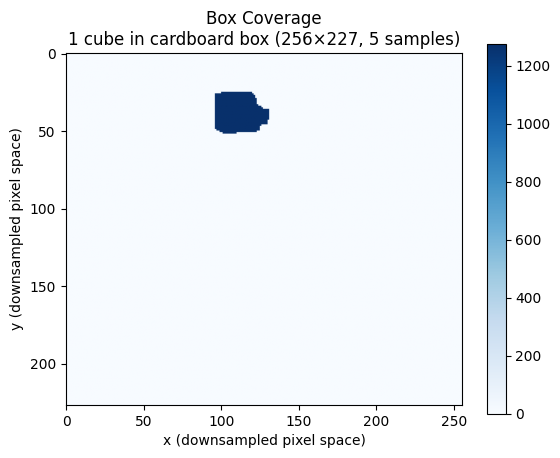

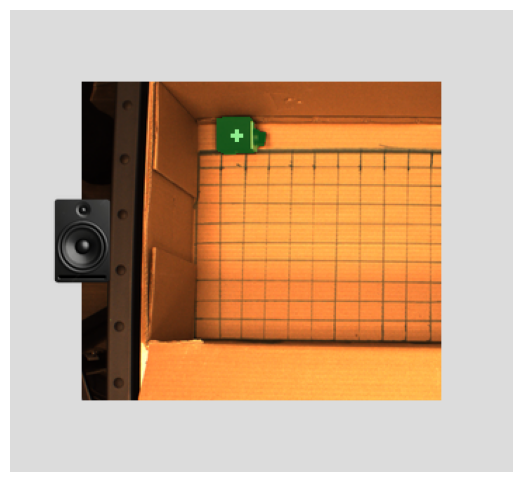

[sample 000004] record vibrations in 241.31 ms


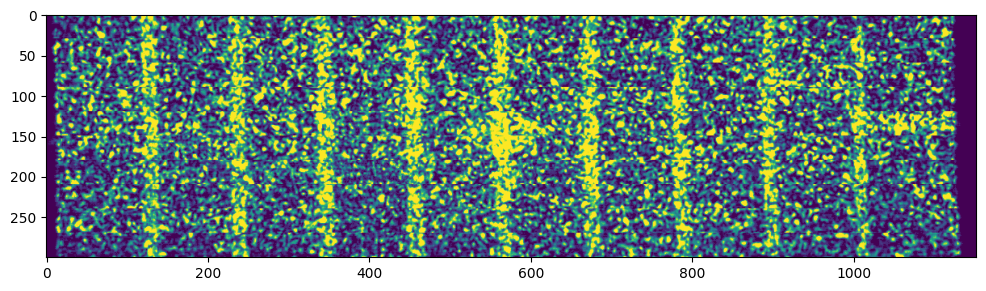

In [100]:
box = 'cardboard'
object = 'cube'
n_objects = 1
prompt = "A black metal cube sitting on the floor of an open cardboard box from a bird's eye view."
description = prompt
resize_params = {"left": 0.05, "right": 0.59, "up": 0.06, "down": 0.7, "max_side": 256}
audio = Path('/home/ethantu/workspace/good-vibrations/data2/chirp_50_1000_3.0sec.wav')

obj_params = dict(object=object, n_objects=n_objects, box=box)
overhead_params = dict(prompt=prompt, description=description, resize_params=resize_params)
vibrate_params = dict(audio=audio, speakers=[3])

# define dummy functions
def capture_image_fxn(x):
    img = load('/home/ethantu/workspace/good-vibrations/data2/00_raw_overhead.png')
    return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR), None
def play_audio_fxn(x, y): pass
def capture_n_frames_fxn(x, y, *args): return load('/home/ethantu/workspace/good-vibrations/data2/speckle_vibration_raw.npy'), None

# define dummy parameters
overhead_cam = None
run_opt = {'cam_params': {'camera_FPS': 5000}}
class cam:
    def __init__(self): pass
    def get_im_size(self): return [0]

run_experiment(obj_params, overhead_params, vibrate_params, box_coverage, cam(), run_opt, overhead_cam, capture_image_fxn, play_audio_fxn, capture_n_frames_fxn, verbose=2)

In [11]:
output_id = make_id(BASE_OUTPUT_DIR)
output_dir = BASE_OUTPUT_DIR / output_id
speaker = vibrate_params['speakers'][0]
sample_id  = make_id(BASE_SAMPLE_DIR)
sample_dir = BASE_SAMPLE_DIR / sample_id
verbose = 2
do_save= True
raw_vibrations = capture_vibrations(cam(), run_opt, speaker, play_audio_fxn, capture_n_frames_fxn, vibrate_params['audio'], sample_dir, output_dir, verbose, do_save)

[sample 000001] record vibrations in 237.92 ms


In [ ]:
def speckle_shifts(vibrations):
    # run pclk
    pass

speckle_shifts(raw_vibrations)